In [1]:
import numpy as np
import pandas as pd
import sklearn.model_selection
import argparse, os, glob, re, warnings, shutil, pysam
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
import statsmodels.api as sm
from Bio import Seq, SeqIO
import scipy.stats as st

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

df_LR_assembly_metadata = pd.read_csv("../data/TRUST.PBAsm.ZA_106CI_AssemblySummary.csv")
df_LR_assembly_metadata['Lineage'] = df_LR_assembly_metadata['Lineage_Asm'].str.replace('lineage', '')

# this keeps only those with NumContigs = 1 and numContigs_Complete = 1 in df_LR_assembly_metadata, and the lineages (Coll2014 exactly) of the LR and SR sequences must match
df_personal_assemblies = pd.read_csv("./data/personal_assemblies_samples.tsv", sep='\t', header=None, names = ['Sample', 'Assembly', 'PacBio'])
samples_with_assemblies = df_personal_assemblies['Sample'].values

df_trust_patients = pd.read_csv("~/TRUST_data_processing/processed_data/20250904_cleaned_patient_outcomes_data.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID
        
    if not pd.isnull(row['Lineage']):
        if type(row['Lineage']) == float:
            df_trust_patients.loc[i, 'Lineage'] = str(int(row['Lineage']))
        else:
            df_trust_patients.loc[i, 'Lineage'] = str(row['Lineage'])
     
print(df_trust_patients.Lineage.value_counts())
            
F2_thresh = 0.03

import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "scripts"))
from epi_utils import *

Lineage
2      363
4      317
3       49
2,4      6
1        1
2,3      1
Name: count, dtype: int64


In [3]:
df_longitudinal_pids = pd.read_csv(f"../data/longitudinal_pids_WGS_data.csv")
print(f"{df_longitudinal_pids.pid.nunique()} pids")

pids_with_low_F2 = pd.DataFrame(df_longitudinal_pids.query("F2 <= @F2_thresh").groupby('pid')['SampleID'].nunique()).query("SampleID > 1").index.values

# # additionally require pids to have had the EXACT same lineage
pids_with_same_lineage = pd.DataFrame(df_longitudinal_pids.groupby('pid')['Coll2014'].nunique()).query("Coll2014 == 1").index.values
pids_with_same_lineage = set(pids_with_same_lineage).intersection(pd.DataFrame(df_longitudinal_pids.groupby('pid')['Freschi2020'].nunique()).query("Freschi2020 == 1").index.values)
pids_with_same_lineage = np.unique(list(pids_with_same_lineage))

print(f"{len(pids_with_same_lineage)}/{df_longitudinal_pids.pid.nunique()} pids have the same lineage assigned to both samples")

include_pids_consistent_mixed_lineages = []

for pid in df_longitudinal_pids.query("pid not in @pids_with_same_lineage and pid not in @pids_with_low_F2").pid.unique():
    lineage_1, lineage_2 = df_longitudinal_pids.query("pid==@pid").Coll2014.unique()
    
    lineage_1 = lineage_1.split(',')
    lineage_2 = lineage_2.split(',')
    
    if len(set(lineage_1).intersection(lineage_2)) > 0:
        include_pids_consistent_mixed_lineages.append(pid)
        
candidate_mixed_pids = df_longitudinal_pids.query("pid not in @pids_with_low_F2").pid.unique()

check_fastlin_samples = list(set(candidate_mixed_pids) - set(include_pids_consistent_mixed_lineages))

for pid in check_fastlin_samples:
    
    samples = df_longitudinal_pids.query("pid==@pid").SampleID.values
    assert len(samples) == 2
    
    fastlin_1 = pd.read_csv(f"{H37Rv_ref_dir}/{samples[0]}/{samples[0]}/fastlin/output.txt", sep='\t')
    fastlin_2 = pd.read_csv(f"{H37Rv_ref_dir}/{samples[1]}/{samples[1]}/fastlin/output.txt", sep='\t')
    
    sample_1_lineages = fastlin_1['lineages'].values[0].split(',')
    sample_1_lineages = [lineage.split(' (')[0].strip() for lineage in sample_1_lineages]
        
    sample_2_lineages = fastlin_2['lineages'].values[0].split(',')
    sample_2_lineages = [lineage.split(' (')[0].strip() for lineage in sample_2_lineages]
         
    if len(set(sample_1_lineages).intersection(sample_2_lineages)) > 0:
        include_pids_consistent_mixed_lineages.append(pid)
        
print(f"{len(include_pids_consistent_mixed_lineages)} pids with mixed lineages have consistent mixing")
        
df_longitudinal_pids = df_longitudinal_pids.query("pid in @pids_with_same_lineage | pid in @include_pids_consistent_mixed_lineages").reset_index(drop=True)
print(f"{df_longitudinal_pids.pid.nunique()} pids remaining for analysis")

pids_with_same_lineage_and_low_F2 = list(set(pids_with_low_F2).intersection(pids_with_same_lineage))
print(f"{len(pids_with_same_lineage_and_low_F2)} pids have F2 ≤ {F2_thresh} and matching lineages between timepoints")

299 pids
278/299 pids have the same lineage assigned to both samples
19 pids with mixed lineages have consistent mixing
291 pids remaining for analysis
271 pids have F2 ≤ 0.03 and matching lineages between timepoints


In [4]:
df_sampling_weeks = pd.DataFrame(df_longitudinal_pids.groupby('pid')['Sampling_Week'].apply(lambda x: np.max(x) - np.min(x))).reset_index()

df_sampling_weeks.Sampling_Week.median(), df_sampling_weeks.Sampling_Week.mean()

(6.0, 5.508591065292096)

<Axes: xlabel='Sampling_Week', ylabel='Count'>

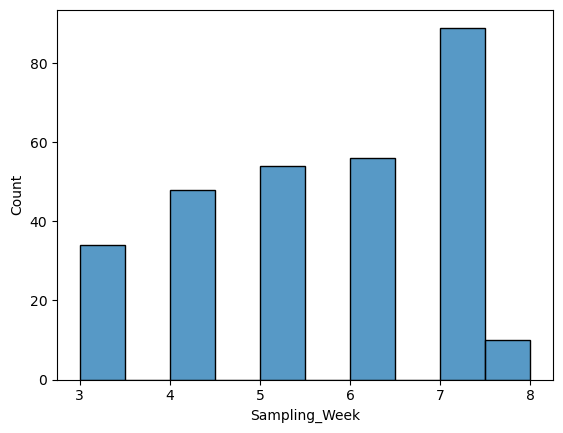

In [5]:
sns.histplot(data=df_sampling_weeks,
             x='Sampling_Week'
            )

# Associate each of the diversity metrics with 3 measures of bacterial burden

In [6]:
# df_lowAF_variants = pd.read_csv("../results/lowAF_variants_255pids.csv")

df_diversity_metrics = pd.read_csv("../results/diversity_metrics_271pids.csv")

df_bacterial_burden = df_trust_patients[['pid', 'TTP_baseline', 
                                         'smear_pos_no_contam_sputum_specimen_1', 'smear_pos_no_contam_sputum_specimen_2',
                                         's_concafb_sputum_specimen_1', 's_concafb_sputum_specimen_2',
                                         'ultra_ct_collapsed',
                                        ]].drop_duplicates().reset_index(drop=True)

# ordinal encoding: bl_afbprog --> smear
smear_encoding_dict = {6: np.nan, # I think this was already done in their data cleaning
                       5: np.nan, # I think this was already done in their data cleaning
                       0: 0, # no AFB
                       4: 1, # scanty
                       1: 2, # +
                       2: 3, # ++
                       3: 4, # +++
                      }

df_bacterial_burden['s_concafb_sputum_specimen'] = df_bacterial_burden['s_concafb_sputum_specimen_1'].fillna(df_bacterial_burden['s_concafb_sputum_specimen_2'])

df_bacterial_burden['smear_positive'] = df_bacterial_burden['smear_pos_no_contam_sputum_specimen_1'].fillna(df_bacterial_burden['smear_pos_no_contam_sputum_specimen_2'])

df_bacterial_burden['smear_grade'] = df_bacterial_burden['s_concafb_sputum_specimen'].map(smear_encoding_dict)

# check that all pids have smear positivity and smear grade measured in the first 2 weeks
assert sum(pd.isnull(df_bacterial_burden['smear_positive'])) == 0
assert sum(pd.isnull(df_bacterial_burden['smear_grade'])) == 0

df_bacterial_burden[['smear_positive', 'smear_grade']] = df_bacterial_burden[['smear_positive', 'smear_grade']].astype(int)

df_diversity_metrics = df_diversity_metrics.merge(df_bacterial_burden[['pid', 'smear_positive', 'smear_grade', 'TTP_baseline', 'ultra_ct_collapsed']], on='pid')

df_diversity_metrics = df_diversity_metrics.merge(df_sampling_weeks, on='pid')

df_diversity_metrics['High_F2'] = (~df_diversity_metrics['pid'].isin(pids_with_low_F2)).astype(int)

df_diversity_metrics.loc[df_diversity_metrics['smear_grade'].isin([0]), 'smear_group'] = 0
df_diversity_metrics.loc[df_diversity_metrics['smear_grade'].isin([1, 2]), 'smear_group'] = 1
df_diversity_metrics.loc[df_diversity_metrics['smear_grade'].isin([3, 4]), 'smear_group'] = 2

print(df_diversity_metrics.smear_group.value_counts().sort_index())

df_diversity_metrics['Long_Sampling_Interval'] = (df_diversity_metrics['Sampling_Week'] >= df_diversity_metrics.Sampling_Week.median()).astype(int)

print(df_diversity_metrics['Long_Sampling_Interval'].value_counts().sort_index())

smear_group
0.0     46
1.0    120
2.0    105
Name: count, dtype: int64
Long_Sampling_Interval
0    127
1    144
Name: count, dtype: int64


In [20]:
bacterial_burden_metrics = ['smear_positive', 'smear_grade', 'TTP_baseline', 'ultra_ct_collapsed']

diversity_metrics = ['F2', 'SASE1', 'SASE2', 'SASE_Diff', 'NumVar', 'NumVar1', 'NumVar2', 'NumVarDiff', 'OverlapVarSites', 'SASE_Diff', 'ChangeSites']
# diversity_metrics = ['F2', 'SASE1', 'SASE_Diff', 'NumVar1', 'NumVarDiff']

In [33]:
def get_var_type(series, max_unique_categorical=10):
    """
    Heuristic to classify variable as categorical or numeric.
    """
    if pd.api.types.is_numeric_dtype(series):
#         if series.nunique() <= max_unique_categorical:
#             return "categorical"
#         else:
#             return "numeric"
        
        return "numeric"
    else:
        return "categorical"
    
    
    
def association_test(x, y):
    """
    Run the appropriate association test depending on variable types.
    Returns a dictionary with test name, statistic, and p-value.
    """
    x_type = get_var_type(x)
    y_type = get_var_type(y)

    # Drop missing
    df = pd.DataFrame({"x": x, "y": y}).dropna()
    x, y = df["x"], df["y"]

    # Continuous × Continuous
    if x_type == "numeric" and y_type == "numeric":
        rho, p = st.spearmanr(x, y)
        return {"test": "Spearman", "stat": rho, "pval": p}

    # Categorical × Categorical
    elif x_type == "categorical" and y_type == "categorical":
        contingency = pd.crosstab(x, y)
        if contingency.shape == (2, 2):
            _, p = st.fisher_exact(contingency)
            test = "Fisher"
        else:
            _, p, _, _ = st.chi2_contingency(contingency)
            test = "Chi-squared"
        return {"test": test, "stat": np.nan, "pval": p}

    # Continuous × Categorical
    else:
        # Ensure continuous is x
        if x_type == "categorical":
            x, y = y, x
        groups = [x[y == level] for level in np.unique(y)]
        if len(groups) == 2:
            stat, p = st.mannwhitneyu(groups[0], groups[1], alternative="two-sided")
            test = "Mann-Whitney U"
        else:
            stat, p = st.kruskal(*groups)
            test = "Kruskal-Wallis"
        return {"test": test, "stat": stat, "pval": p}

In [34]:
def generate_association_matrix(df, vars1, vars2, all_samples=False):
    """
    Test all associations between two variable lists.
    """
    results = []
    for x in vars1:
        for y in vars2:

            if all_samples:
                df_test = df[[x, y]].dropna()
            else:
                if x == 'F2':
                    df_test = df[[x, y]].dropna()
                else:
                    df_test = df.query("pid in @pids_with_low_F2")[[x, y]].dropna()

            res = association_test(df_test[x], df_test[y])
            res.update({"var1": x, "var2": y, "numSamples": len(df_test)})
            results.append(res)
            
    return pd.DataFrame(results, columns=["var1", "var2", "test", "stat", "pval", "numSamples"])

In [35]:
df_associations = generate_association_matrix(df_diversity_metrics, diversity_metrics, bacterial_burden_metrics)
# df_associations_all_samples = generate_association_matrix(df_diversity_metrics, diversity_metrics, bacterial_burden_metrics, all_samples=True)

In [36]:
df_diversity_metrics['smear_grade'].value_counts().sort_index()

smear_grade
0    46
1    86
2    34
3    58
4    47
Name: count, dtype: int64

In [37]:
df_diversity_metrics['smear_positive'].value_counts().sort_index()

smear_positive
0     46
1    225
Name: count, dtype: int64

In [38]:
st.spearmanr(df_diversity_metrics['F2'],
             df_diversity_metrics['NumVar1']
            )

SignificanceResult(statistic=0.04710323732023372, pvalue=0.4399594730899947)

In [39]:
df_diversity_metrics.query("ChangeSites < 8").TTP_baseline.mean(), df_diversity_metrics.query("ChangeSites >= 8").TTP_baseline.mean()

(196.72413793103448, 207.74285714285713)

In [41]:
df_associations.sort_values('pval').query("pval <= 0.1")

,var1,var2,test,stat,pval,numSamples
42,ChangeSites,TTP_baseline,Spearman,0.124878,0.041457,267
23,NumVar1,ultra_ct_collapsed,Spearman,0.157140,0.046510,161
43,ChangeSites,ultra_ct_collapsed,Spearman,0.138323,0.080142,161
2,F2,TTP_baseline,Spearman,-0.104511,0.088309,267
0,F2,smear_positive,Spearman,0.101523,0.095341,271
1,F2,smear_grade,Spearman,0.101163,0.096530,271


In [49]:
df_associations_all_samples.sort_values('pval').query("pval <= 0.2")

,var1,var2,test,stat,pval,numSamples
2,F2,TTP_baseline,Spearman,-0.113202,0.055852,286
0,F2,smear_positive,Mann-Whitney U,5076.000000,0.112504,291
3,F2,ultra_ct_collapsed,Spearman,-0.104180,0.168819,176
15,NumVar1,ultra_ct_collapsed,Spearman,0.101045,0.182078,176
8,SASE_Diff,smear_positive,Mann-Whitney U,6618.500000,0.199311,291


In [50]:
df_diversity_metrics.groupby('smear_positive')[['F2', 'NumVar1'] + ['Sampling_Week']].mean()

,F2,NumVar1,Sampling_Week
smear_positive,,,
0,0.014278,50.714286,4.714286
1,0.021929,46.979339,5.669421


In [51]:
st.mannwhitneyu(df_diversity_metrics.query("smear_positive==0")['F2'],
                df_diversity_metrics.query("smear_positive==1")['F2'],
                alternative='less'
               )

MannwhitneyuResult(statistic=5076.0, pvalue=0.05625179728743436)

In [52]:
st.mannwhitneyu(df_diversity_metrics.query("smear_positive==0")['NumVar1'],
                df_diversity_metrics.query("smear_positive==1")['NumVar1'],
                alternative='less'
               )

MannwhitneyuResult(statistic=5758.0, pvalue=0.3731518783505383)

In [53]:
df_diversity_metrics.groupby(['High_F2', 'smear_positive'])[['SASE_Diff'] + ['Sampling_Week']].mean()

SASE_Diff  Sampling_Week
High_F2 smear_positive                          
0       0                0.087537       4.695652
        1                0.030664       5.662222
1       0               -0.156733       5.000000
        1               -0.359929       5.764706

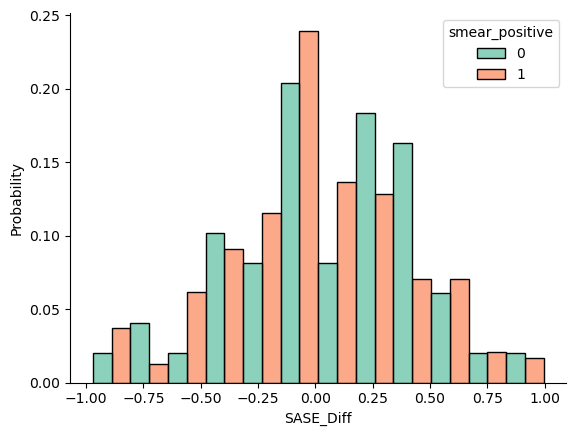

In [54]:
sns.histplot(data=df_diversity_metrics,
             x='SASE_Diff',
             hue='smear_positive',
             multiple='dodge',
             common_norm=False,
             stat='probability',
             palette='Set2'
            )

sns.despine()
# plt.savefig("../results/figures/SE_diff_by_smear_positivity.svg", bbox_inches='tight')

In [55]:
df_diversity_metrics.query("pid in @pids_with_low_F2").groupby('smear_grade')[['SASE1', 'SASE2', 'SASE_Diff', 'Sampling_Week']].mean()

,SASE1,SASE2,SASE_Diff,Sampling_Week
smear_grade,,,,
0,0.364346,0.451883,0.087537,4.695652
1,0.382814,0.440426,0.057611,5.686047
2,0.425648,0.409334,-0.016315,5.264706
3,0.418460,0.433999,0.015539,5.827586
4,0.403680,0.437684,0.034004,5.702128


In [56]:
df_diversity_metrics.groupby('smear_grade')[['SASE1', 'SASE2', 'SASE_Diff', 'Sampling_Week']].mean()

,SASE1,SASE2,SASE_Diff,Sampling_Week
smear_grade,,,,
0,0.374730,0.447311,0.072581,4.714286
1,0.399437,0.432980,0.033544,5.680851
2,0.443427,0.391735,-0.051692,5.243243
3,0.433954,0.416652,-0.017302,5.852459
4,0.418354,0.430263,0.011909,5.740000


https://pmc.ncbi.nlm.nih.gov/articles/PMC7195533/

# Normalize diversity metrics to sampling interval

In [57]:
df_diversity_metrics['SASE_Diff_norm_interval'] = df_diversity_metrics['SASE_Diff'] / df_diversity_metrics['Sampling_Week']
df_diversity_metrics['NumVarDiff_norm_interval'] = df_diversity_metrics['NumVarDiff'] / df_diversity_metrics['Sampling_Week']

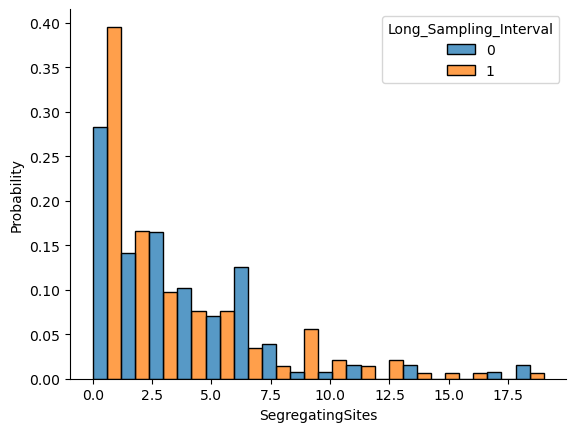

In [71]:
sns.histplot(data=df_diversity_metrics.query("pid in @pids_with_low_F2"),
             x='SegregatingSites',
             hue='Long_Sampling_Interval',
             multiple='dodge',
             common_norm=False,
             stat='probability'
            )

sns.despine()
plt.show()

In [75]:
df_diversity_metrics.query("NumVarDiff < -10 & pid in @pids_with_low_F2")

,pid,SE1,SE2,SASE1,SASE2,NumVar1,NumVar2,NumVar,OverlapVarSites,SegregatingSites,...,smear_positive,smear_grade,TTP_baseline,ultra_ct_collapsed,Sampling_Week,High_F2,smear_group,Long_Sampling_Interval,SASE_Diff_norm_interval,NumVarDiff_norm_interval
48,T0067,0.0,0.0,0.460423,0.0,18,0,18,0,18,...,1,1,171.0,18.975,6,0,1.0,1,-0.076737,-3.0


In [72]:
df_diversity_metrics.query("pid in @pids_with_low_F2").groupby('Long_Sampling_Interval')['SegregatingSites'].agg(['mean', 'median'])

,mean,median
Long_Sampling_Interval,,
0,3.763780,3.0
1,3.444444,2.0


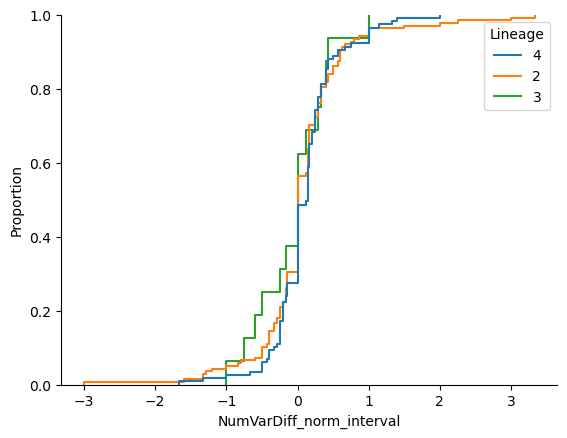

In [80]:
sns.ecdfplot(data=df_diversity_metrics.query("pid in @pids_with_low_F2"),
             x='NumVarDiff_norm_interval',
             hue='Lineage',
             # multiple='dodge',
             # common_norm=False,
             # stat='probability'
            )

sns.despine()
plt.show()

In [30]:
st.spearmanr(df_diversity_metrics.query("pid in @pids_with_low_F2")['smear_grade'],
             df_diversity_metrics.query("pid in @pids_with_low_F2")['NumVarDiff'], 
            )

SignificanceResult(statistic=0.06279785338916762, pvalue=0.3029998727138866)

In [31]:
st.spearmanr(df_diversity_metrics.query("pid in @pids_with_low_F2")['smear_grade'],
             df_diversity_metrics.query("pid in @pids_with_low_F2")['NumVarDiff_norm_interval'], 
            )

SignificanceResult(statistic=0.05431318003952209, pvalue=0.37312636687321044)

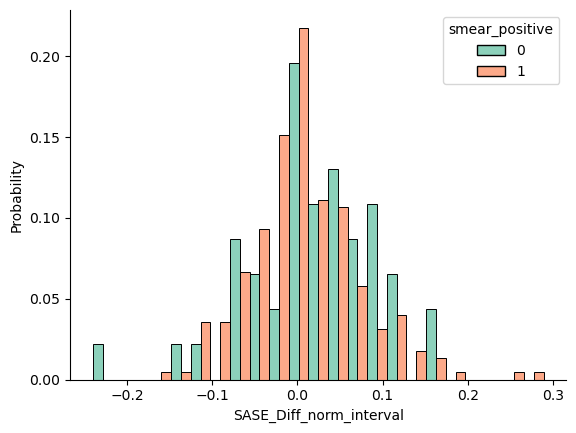

In [164]:
sns.histplot(data=df_diversity_metrics.query("pid in @pids_with_low_F2"),
             x='SASE_Diff_norm_interval',
             hue='smear_positive',
             multiple='dodge',
             common_norm=False,
             stat='probability',
             palette='Set2'
            )

sns.despine()
# plt.savefig("../results/figures/SE_diff_by_smear_positivity.svg", bbox_inches='tight')

In [23]:
df_diversity_metrics.query("pid in @pids_with_low_F2").groupby('smear_grade')[['SASE1', 'SASE2', 'SASE_Diff', 'Sampling_Week', 'SASE_Diff_norm_interval']].mean()

,SASE1,SASE2,SASE_Diff,Sampling_Week,SASE_Diff_norm_interval
smear_grade,,,,,
0,0.364346,0.451883,0.087537,4.695652,0.018802
1,0.382814,0.440426,0.057611,5.686047,0.013835
2,0.425648,0.409334,-0.016315,5.264706,-0.002621
3,0.418460,0.433999,0.015539,5.827586,0.005377
4,0.403680,0.437684,0.034004,5.702128,0.008465


In [33]:
df_diversity_metrics.query("pid in @pids_with_low_F2").groupby('smear_positive')[['SASE1', 'SASE2', 'SASE_Diff', 'Sampling_Week', 'SASE_Diff_norm_interval']].mean()

,SASE1,SASE2,SASE_Diff,Sampling_Week,SASE_Diff_norm_interval
smear_positive,,,,,
0,0.364346,0.451883,0.087537,4.695652,0.018802
1,0.402834,0.433498,0.030664,5.662222,0.008046


In [34]:
df_diversity_metrics.query("pid in @pids_with_low_F2").groupby('smear_grade')[['NumVar1', 'NumVar2', 'NumVarDiff', 'Sampling_Week', 'NumVarDiff_norm_interval']].mean()

,NumVar1,NumVar2,NumVarDiff,Sampling_Week,NumVarDiff_norm_interval
smear_grade,,,,,
0,1.934783,2.152174,0.217391,4.695652,0.046170
1,2.290698,2.453488,0.162791,5.686047,0.054720
2,2.323529,2.764706,0.441176,5.264706,0.071919
3,2.448276,2.931034,0.482759,5.827586,0.090415
4,1.914894,2.787234,0.872340,5.702128,0.181966


In [35]:
df_diversity_metrics.query("pid in @pids_with_low_F2").groupby('smear_positive')[['NumVar1', 'NumVar2', 'NumVarDiff', 'Sampling_Week', 'NumVarDiff_norm_interval']].mean()

,NumVar1,NumVar2,NumVarDiff,Sampling_Week,NumVarDiff_norm_interval
smear_positive,,,,,
0,1.934783,2.152174,0.217391,4.695652,0.046170
1,2.257778,2.693333,0.435556,5.662222,0.093101


In [39]:
st.mannwhitneyu(df_diversity_metrics.query("pid in @pids_with_low_F2").query("smear_positive==0")['NumVarDiff'],
                df_diversity_metrics.query("pid in @pids_with_low_F2").query("smear_positive==1")['NumVarDiff'],
                alternative='less'
               )

MannwhitneyuResult(statistic=4892.5, pvalue=0.2773164611755998)

In [40]:
st.mannwhitneyu(df_diversity_metrics.query("pid in @pids_with_low_F2").query("smear_positive==0")['NumVarDiff_norm_interval'],
                df_diversity_metrics.query("pid in @pids_with_low_F2").query("smear_positive==1")['NumVarDiff_norm_interval'],
                alternative='less'
               )

MannwhitneyuResult(statistic=4982.5, pvalue=0.34480265420491113)

In [84]:
st.spearmanr(df_diversity_metrics.query("pid in @pids_with_low_F2")['smear_group'],
            df_diversity_metrics.query("pid in @pids_with_low_F2")['NumVarDiff_norm_interval']
            )

SignificanceResult(statistic=0.05025659846531376, pvalue=0.4099255408782717)

In [85]:
st.spearmanr(df_diversity_metrics.query("pid in @pids_with_low_F2")['smear_group'],
            df_diversity_metrics.query("pid in @pids_with_low_F2")['NumVarDiff']
            )

SignificanceResult(statistic=0.05837554141276153, pvalue=0.3383869229086386)

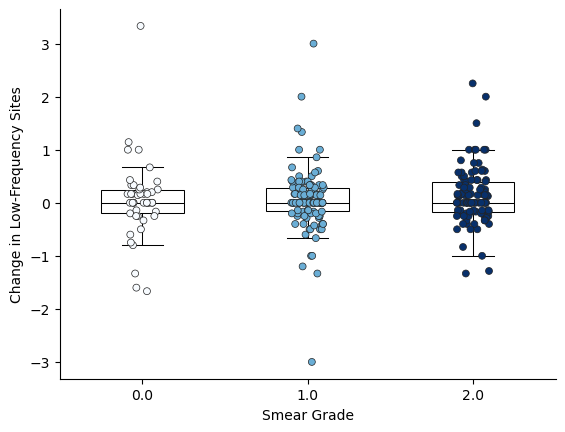

In [82]:
group_var = 'smear_group'
plot_var = 'NumVarDiff_norm_interval'

fig, ax = plt.subplots()

sns.stripplot(data=df_diversity_metrics.query("pid in @pids_with_low_F2"),
              x=group_var,
              y=plot_var,
              ax=ax,
              # edgecolor='black',
              hue=group_var,
              linewidth=0.5,
              palette='Blues',
              legend=False
             )

sns.boxplot(data=df_diversity_metrics.query("pid in @pids_with_low_F2"),
              x=group_var,
              y=plot_var,
              ax=ax,
            color='white',
            linecolor='black',
            fliersize=0,
            width=0.5,
            linewidth=0.75,
             )

plt.xlabel('Smear Grade')
plt.ylabel('Change in Low-Frequency Sites')

sns.despine()

In [83]:
# plot_var = 'NumVarDiff'

# fig, ax = plt.subplots()

# sns.stripplot(data=df_diversity_metrics.query("pid in @pids_with_low_F2"),
#               x='smear_grade',
#               y=plot_var,
#               ax=ax,
#               # edgecolor='black',
#               hue='smear_grade',
#               linewidth=0.5,
#               palette='Blues',
#               legend=False
#              )

# sns.boxplot(data=df_diversity_metrics.query("pid in @pids_with_low_F2"),
#               x='smear_grade',
#               y=plot_var,
#               ax=ax,
#             color='white',
#             linecolor='black',
#             fliersize=0,
#             linewidth=0.75,
#             width=0.5,
#              )

# plt.xlabel('Smear Grade')
# plt.ylabel('Change in Low-Frequency Sites')

# sns.despine()

# Associate Diversity Metrics with Treatment Outcomes

In [102]:
cols_lst = [
            'screen_sex',
            'screen_years',
            'underweight',
            'fstrom1_baseline', # smoking yes or no
            'smoked_substance_use',
            'peth_value_baseline',
            'HIV_CD4',
            'bl_prevtb',
            # 'TTP_baseline',
            # 'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            'high_lung_involvement',
            'Lineage' # Lineage_3 is so rare and causes instabilities / needs to be stratified by
           ]


# try these first, as they were required for the full TCC model
# stratify_covariates = ['smear_pos_no_contam_sputum_specimen_1', 'HIV_CD4', 'high_lung_involvement']
stratify_covariates = ['HIV_CD4', 'high_lung_involvement']

non_linear_term_variables = []

TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_imputed_TCC = pd.read_csv(f"{TRUST_data_dir}/imputed_TCC.csv").query("pid in @df_trust_patients.pid")

del_cols = ['F2', 'Lineage', 'Coll2014', 'Freschi2020']

CNN_results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

df_pids_for_outcomes_model, TRUST_phenos, df_pred_combined = read_combine_all_TRUST_data(df_trust_patients, 
                                                                                         {'RIF': 'lineage_amino_acid',
                                                                                          'INH': 'lineage_amino_acid',
                                                                                          'EMB': 'lineage_amino_acid',
                                                                                          'PZA': 'amino_acid'}, 
                                                                                         CNN_results_dir,
                                                                                         F2_thresh=1, 
                                                                                         baseline_only=True
                                                                                        )

df_pids_for_outcomes_model = df_pids_for_outcomes_model.query("pid in @df_longitudinal_pids.pid").drop_duplicates(subset='pid').reset_index(drop=True)

df_pids_for_outcomes_model['inh_resistant'] = (df_pids_for_outcomes_model['pid'].isin(TRUST_phenos.query("INH_lower_bound >= 0.1").pid.values)).astype(int)

df_pids_for_outcomes_model['underweight'] = (df_pids_for_outcomes_model['bl_bmi'] < 18).astype(int)

len(df_pids_for_outcomes_model), df_pids_for_outcomes_model.pid.nunique()

406 patients with uncontaminated WGS samples
400 patients with uncontaminated WGS samples taken in the first 2 weeks

4 patients: ['T0402' 'T0206' 'T0042' 'T0170'] have multiple sequences at the same timepoint
Removing 1 patients: ['T0402'] because there are multiple WGS samples at the same timepoint with different lineages
401 patients have MICs for RIF
401 patients have MICs for INH
401 patients have MICs for EMB
280 patients have MICs for PZA
397 patients have measured MICs in the first 2 weeks

Found predicted RIF MICs for 399 pids
Found predicted INH MICs for 399 pids
Found predicted EMB MICs for 399 pids
Found predicted PZA MICs for 399 pids
399 patients have predicted MICs


(290, 290)

In [103]:
df_test_results, df_samples_imputations, cph_models_imputations = fit_cox_models_all_imputations(df_pids_for_outcomes_model,
                                                                                                  df_pred_combined,
                                                                                                   TRUST_phenos,
                                                                                                  df_imputed_TCC,
                                                                                                  cols_lst,
                                                                                                  event_col = 'culture_convert',
                                                                                                  time_col = 'TCC',
                                                                                                 MIC_type = 'none',
                                                                                                 include_drugs = ['INH'],
                                                                                                  invert_OR=True,
                                                                                                  stratify_variables=stratify_covariates,
                                                                                                 binary_lineage=True
                                                                                                 )

df_violating_covariates = []

for model_idx in range(len(cph_models_imputations)):

    df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], df_samples_imputations[model_idx], time_transform='rank').summary

    # diabetes has a p-value of like 0.0105
    violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
    violating_covariates['imp_num'] = model_idx + 1

    df_violating_covariates.append(violating_covariates)

df_violating_covariates = pd.concat(df_violating_covariates)

# convert to HR per 10 years
OR_col = 'HR_TCC_assoc'
df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_test_results.loc[df_test_results['covariate']=='screen_years', [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**10

    275 total pids


In [104]:
df_violating_covariates.query("p <= 0.01").covariate.value_counts()#.drop_duplicates('covariate')

Series([], Name: count, dtype: int64)

In [105]:
df_test_results.sort_values('pval')[['covariate', 'pval', f"{OR_col}_lower", f"{OR_col}_upper"]]

,covariate,pval,HR_TCC_assoc_lower,HR_TCC_assoc_upper
6,screen_years,0.003774,1.080888,1.485118
0,Lineage_2,0.087888,0.957711,1.857513
8,underweight,0.201948,0.889703,1.732538
4,peth_value_baseline,0.230028,0.999784,1.000894
2,diabetes,0.234782,0.295855,1.350689
3,fstrom1_baseline,0.251740,0.550051,1.170593
7,smoked_substance_use,0.397841,0.804020,1.727074
5,screen_sex,0.626628,0.615122,1.341305
1,bl_prevtb,0.689185,0.644945,1.337205


In [113]:
diversity_metric = 'SASE1'

df_add_metric_for_model = df_pids_for_outcomes_model.merge(df_diversity_metrics[['pid', diversity_metric]])

df_test_results_indel, _, _ = fit_cox_models_all_imputations(df_add_metric_for_model,
                                                              df_pred_combined, 
                                                                TRUST_phenos,
                                                              df_imputed_TCC,
                                                             cols_lst + [diversity_metric],
                                                              event_col = 'culture_convert',
                                                              time_col = 'TCC',
                                                              invert_OR=True,
                                                             # MIC_type = 'measured',
                                                            # include_drugs = ['INH'],
                                                              stratify_variables=stratify_covariates,
                                                             binary_lineage=True
                                                             )

    275 total pids


In [114]:
df_test_results_indel.sort_values('pval')[['covariate', 'pval', OR_col, f"{OR_col}_lower", f"{OR_col}_upper"]]

,covariate,pval,HR_TCC_assoc,HR_TCC_assoc_lower,HR_TCC_assoc_upper
7,screen_years,0.003530,1.024054,1.007959,1.040407
0,Lineage_2,0.085913,1.335950,0.959491,1.860113
9,underweight,0.200093,1.244436,0.889808,1.740400
3,diabetes,0.229443,0.626697,0.291701,1.346408
5,peth_value_baseline,0.231164,1.000338,0.999783,1.000894
4,fstrom1_baseline,0.260847,0.805387,0.551604,1.175932
8,smoked_substance_use,0.408459,1.175315,0.799879,1.726967
6,screen_sex,0.625701,0.908086,0.614921,1.341017
2,bl_prevtb,0.674144,0.924876,0.641451,1.333534
1,SASE1,0.856002,0.953561,0.569004,1.598020


In [ ]:
df_results_all_SNPs = []

# test only variants that have are fixed (AF > 0.95) in at least one sample at baseline. Don't include variants thare never fixed at baseline.
test_variants_lst = pd.DataFrame(sample_1_variants.max(axis=0)).reset_index().rename(columns={'index': 'variant', 0:'AF_max'}).query("AF_max > 0.95")['variant'].values

# remove these 4 and add
test_variants_lst = list(set(test_variants_lst) - set(['Rv0759c_c.-97_-96delGG', 'Rv0759c_c.-96delG', 'htrA_c.-38_-37insG', 'htrA_c.-38_-37insGG']))

print(f"Testing associations between TCC and {len(test_variants_lst)} phase variants")

for variant in ['espR_c.-145_-144insG']: #test_variants_lst:

    print(f"Testing {variant}")

    df_imputed_patient_data_single_variant = add_change_to_indel_to_patient_data(df_pids_for_outcomes_model, 
                                                                                     sample_1_variants,
                                                                              sample_2_variants,
                                                                              indels_difference,
                                                                                     variant,
                                                                                     freq_thresh=2,
                                                                                     )

    # will be None if there are not enough patients with the specified change in the indel
    if df_imputed_patient_data_single_variant is not None:
    
#         pids_with_change = indels_difference_grouped_pathways.loc[(indels_difference_grouped_pathways[variant] >= 0.1) | (indels_difference_grouped_pathways[variant] <= -0.1)].index.values
        
#         # only include the Indel_Change variable if is at least 1 patient in each even / no event group with an AF change. Otherwise, you get perfect separation
#         # of the groups, and the hazard ratio estimates will be huge and unreliable
#         if df_imputed_TCC.loc[df_imputed_TCC['imp_num']==0].query("pid in @pids_with_change")['culture_convert'].nunique() == 2:
#             predictors_lst = final_patient_predictors + ['inh_resistant', 'Lineage'] + ['Indel_Sample1', 'Indel_Change']
#         else:
#             predictors_lst = final_patient_predictors + ['inh_resistant', 'Lineage'] + ['Indel_Sample1']

        df_test_results_indel, _, _ = fit_cox_models_all_imputations(df_imputed_patient_data_single_variant,
                                                                      df_pred_combined, 
                                                                        TRUST_phenos,
                                                                      df_imputed_TCC,
                                                                     cols_lst + ['Indel_Change'],
                                                                      event_col = 'culture_convert',
                                                                      time_col = 'TCC',
                                                                      invert_OR=True,
                                                                     MIC_type = 'measured',
                                                                    include_drugs = ['INH'],
                                                                      stratify_variables=stratify_covariates,
                                                                     binary_lineage=True
                                                                     )

    
        df_test_results_indel['Indel'] = variant
    
        df_results_all_indels.append(df_test_results_indel)
        
# paired_variants_lst = [['Rv0759c_c.-96delG', 'Rv0759c_c.-97_-96delGG'],
#                        ['htrA_c.-38_-37insG', 'htrA_c.-38_-37insGG']
#                       ]

# for variants_lst in paired_variants_lst:
    
#     df_imputed_patient_data_single_variant = df_pids_for_outcomes_model.merge(sample_1_variants[variants_lst], left_on='pid', right_index=True)

#     # messes with the names (underscores, periods), so rename
#     df_imputed_patient_data_single_variant.rename(columns={variants_lst[0]: 'Indel_1', variants_lst[1]: 'Indel_2'}, inplace=True)

#     df_test_results_indel, _, _ = fit_cox_models_all_imputations(df_imputed_patient_data_single_variant,
#                                                                   df_pred_combined,
#                                                                    TRUST_phenos,
#                                                                   df_imputed_TCC,
#                                                                  cols_lst + ['Indel_1', 'Indel_2'],
#                                                                   event_col = 'culture_convert',
#                                                                   time_col = 'TCC',
#                                                                   invert_OR=True,
#                                                                   MIC_type = 'measured',
#                                                                 include_drugs = ['INH'],
#                                                                   stratify_variables=stratify_covariates,
#                                                                  binary_lineage=True
#                                                                  )
    
#     df_test_results_indel['Indel'] = variants_lst[0].split('_')[0]
#     df_results_all_indels.append(df_test_results_indel)
    
df_results_all_indels = pd.concat(df_results_all_indels)

# fName = "./results/TCC/indel_change_lowF2.csv"

# df_results_all_indels.to_csv(fName, index=False)
# df_results_all_indels = pd.read_csv(fName)

# Associate changes in each of the SNPs with outcomes

In [ ]:
def get_SNP_changes_single_pid(pid, AF_thresh=0.9, change_thresh=0):
    '''
    This function returns all sites where either Sample 1 or Sample 2 is unfixed. 
    '''
    
    # remove sites that are fixed (AF > 0.95) in both. Keep those that are fixed in one and not the other though
    single_pid_results = pd.DataFrame(sample_1_SNPs.loc[pid]).rename(columns={pid: 'Sample1'})
    single_pid_results = single_pid_results.merge(pd.DataFrame(sample_2_SNPs.loc[pid]).rename(columns={pid: 'Sample2'}), left_index=True, right_index=True)
    single_pid_results = single_pid_results.merge(pd.DataFrame(SNP_differences.loc[pid]).query(f"{pid} != 0").rename(columns={pid: 'Diff'}), left_index=True, right_index=True)

    single_pid_results = single_pid_results.loc[(single_pid_results['Diff'] >= change_thresh) | 
                                                (single_pid_results['Diff'] <= -change_thresh)
                                               ].query("~(Sample1 > @AF_thresh & Sample2 > @AF_thresh)")

    # add SNP effects
    single_pid_results = single_pid_results.merge(df_variants[['SNP', 'GENE', 'Variant_Type']].drop_duplicates(), left_index=True, right_on='SNP')#.set_index('SNP')

    single_pid_results['PositiveChange'] = (single_pid_results['Diff'] > 0).astype(int)
    
    return single_pid_results

In [ ]:
df_large_SNP_changes = []

for pid in df_longitudinal_pids.query("pid in @pids_with_low_F2").pid.unique():
    
    single_pid_results = get_SNP_changes_single_pid(pid)
    single_pid_results['pid'] = pid
    
    df_large_SNP_changes.append(single_pid_results)
    
df_large_SNP_changes = pd.concat(df_large_SNP_changes)